## Heart Disease Detection

The dataset has 1190 entries and 12 columns. This dataset contains data about patient vitals and heart disease (if any) of the same.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('dataset.csv')
data.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [6]:
data.tail()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1
1189,38,1,3,138,175,0,0,173,0,0.0,1,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [8]:
data['target'].value_counts()

target
1    629
0    561
Name: count, dtype: int64

In [9]:
data.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [10]:
data.duplicated().sum()

np.int64(272)

In [11]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()


np.int64(0)

In [12]:
data.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [13]:
for col in data.columns:
    print(col,data[col].unique())


age [40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71]
sex [1 0]
chest pain type [2 3 4 1]
resting bp s [140 160 130 138 150 120 110 136 115 100 124 113 125 145 112 132 118 170
 142 190 135 180 108 155 128 106  92 200 122  98 105 133  95  80 137 185
 165 126 152 116   0 144 154 134 104 139 131 141 178 146 158 123 102  96
 143 172 156 114 127 101 174  94 148 117 192 129 164]
cholesterol [289 180 283 214 195 339 237 208 207 284 211 164 204 234 273 196 201 248
 267 223 184 288 215 209 260 468 188 518 167 224 172 186 254 306 250 177
 227 230 294 264 259 175 318 216 340 233 205 245 194 270 213 365 342 253
 277 202 297 225 246 412 265 182 218 268 163 529 100 206 238 139 263 291
 229 307 210 329 147  85 269 275 179 392 466 129 241 255 276 282 338 160
 156 272 240 393 161 228 292 388 166 247 331 341 243 279 198 249 168 603
 159 190 185 290 212 231 222 235 320 187 266 287 404 312 251 328 285 2

In [14]:
(data==0).sum()

age                      0
sex                    193
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar    704
resting ecg            552
max heart rate           0
exercise angina        547
oldpeak                368
ST slope                 1
target                 410
dtype: int64

In [15]:
data['resting bp s'].isnull().sum()
data['cholesterol'].isnull().sum()
data['ST slope'].isnull().sum()

np.int64(0)

In [16]:
data = data.replace({'resting bp s':0},np.nan)
data = data.replace({'cholesterol':0},np.nan)
data = data.replace({'ST slope':0},np.nan)

In [17]:
data.isnull().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                 1
target                   0
dtype: int64

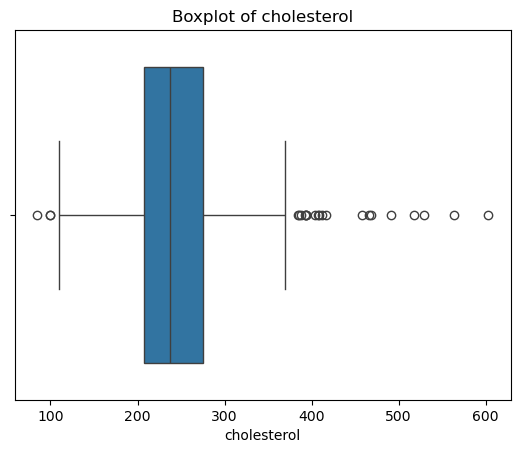

In [18]:
# Boxplot for checking if any outliers are present or not.
sns.boxplot(x=data['cholesterol'])
plt.title("Boxplot of cholesterol")
plt.show()

In [19]:
# Imputation.
data['cholesterol'].fillna(data['cholesterol'].median(), inplace=True)
data.isnull().sum()


C:\Users\Adarsh tayade\AppData\Local\Temp\ipykernel_13932\2767303124.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['cholesterol'].fillna(data['cholesterol'].median(), inplace=True)


age                    0
sex                    0
chest pain type        0
resting bp s           1
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               1
target                 0
dtype: int64

In [20]:
data.dropna(subset=['resting bp s','ST slope'],inplace=True)
data.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

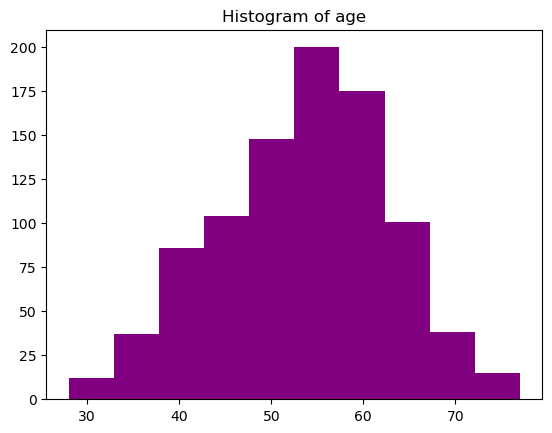

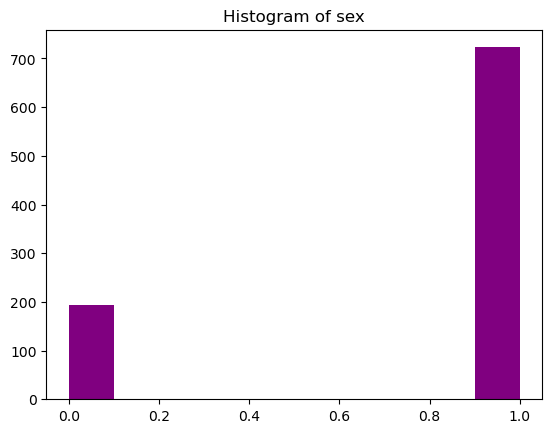

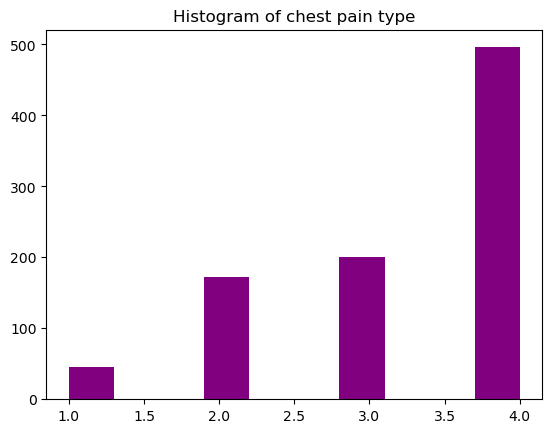

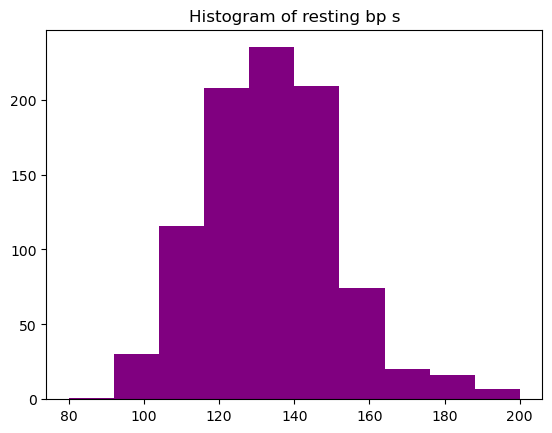

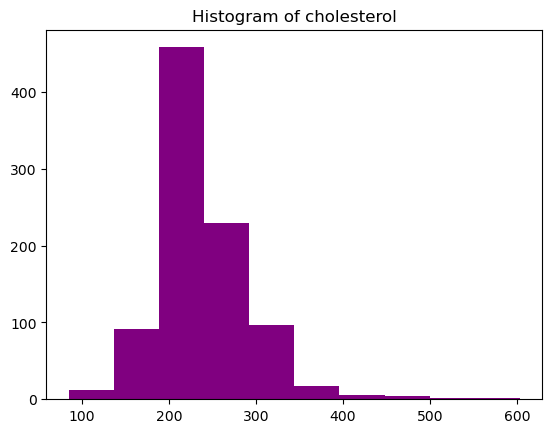

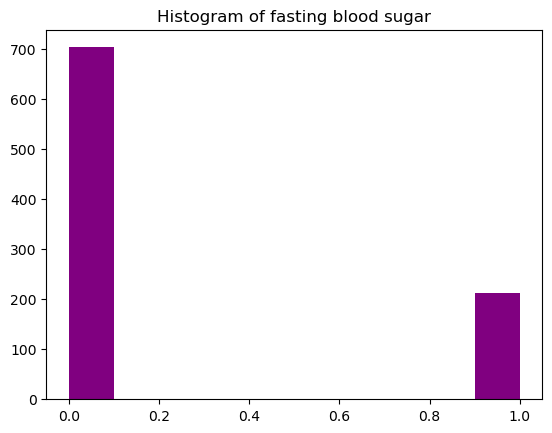

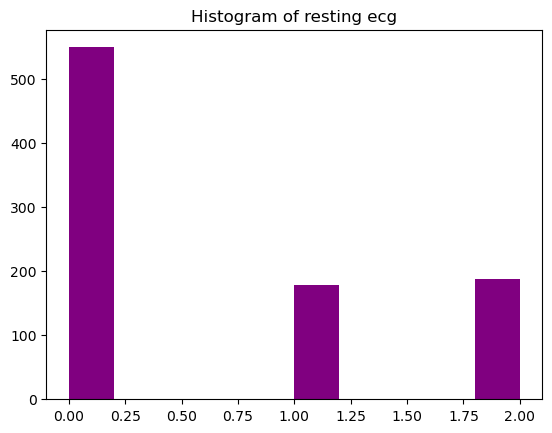

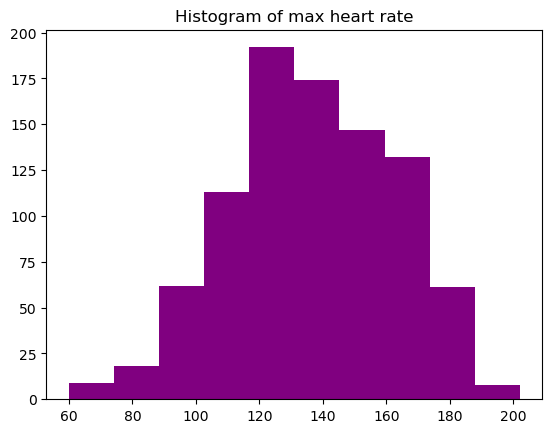

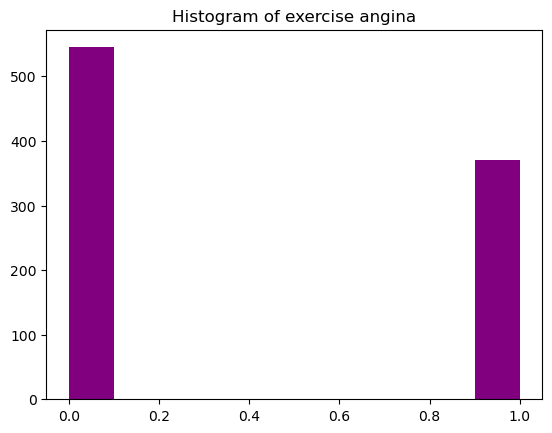

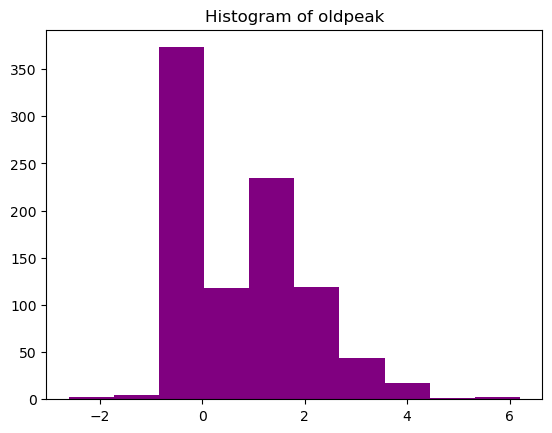

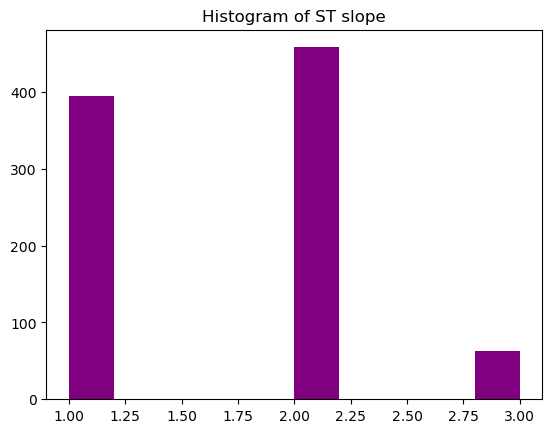

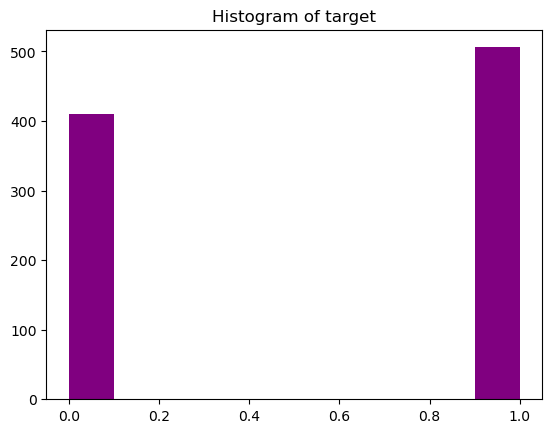

In [21]:
# Histogram for Every feature
for col in data.columns:
    plt.hist(data[col],bins=10,color='purple')
    plt.title(f"Histogram of {col}")
    plt.show()


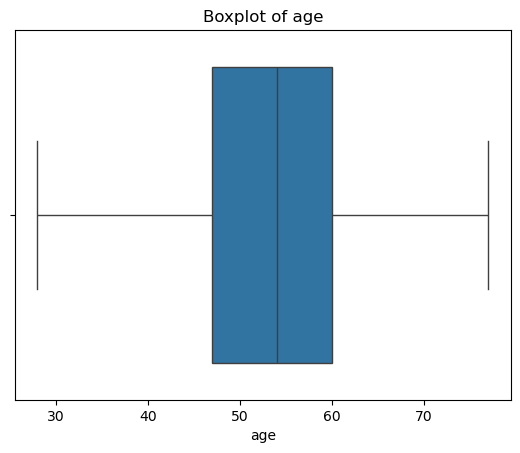

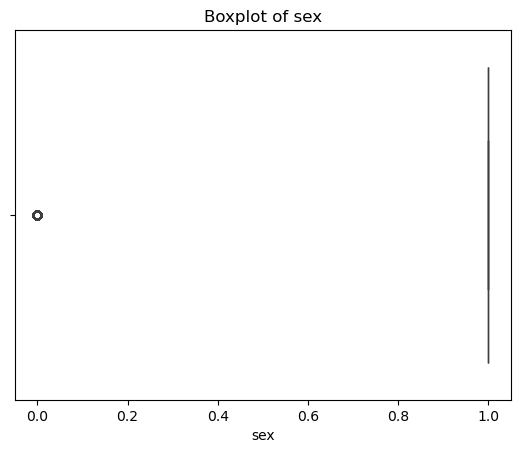

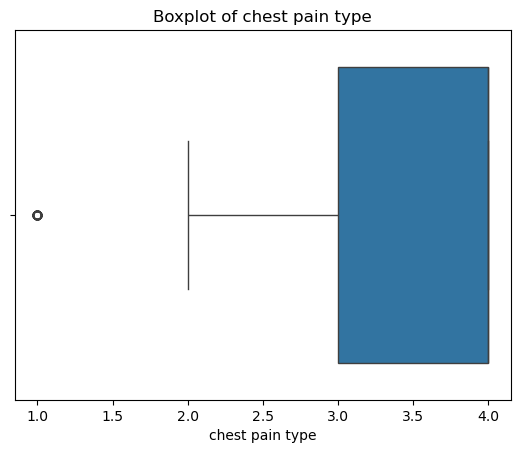

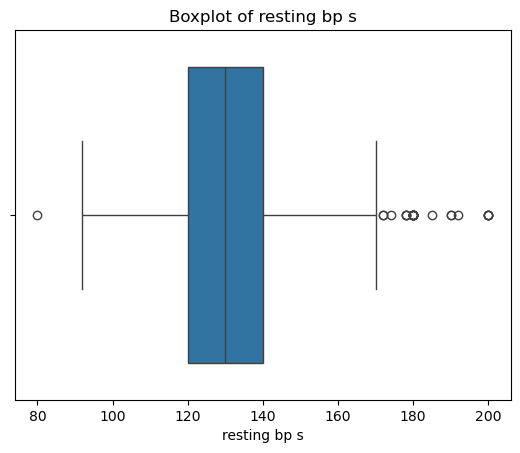

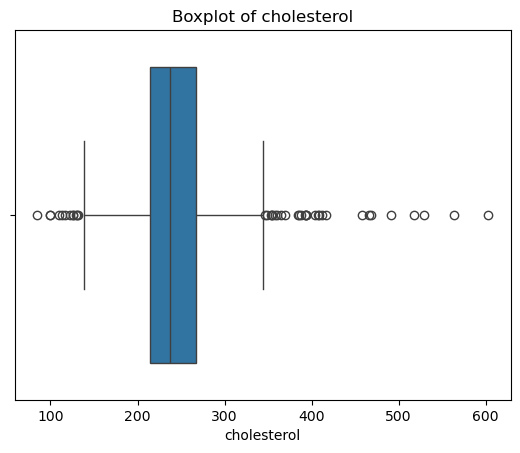

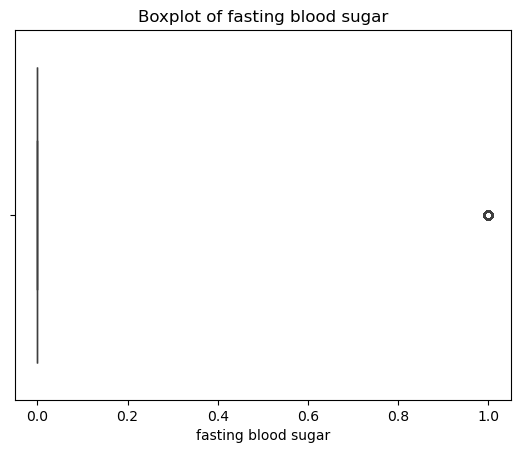

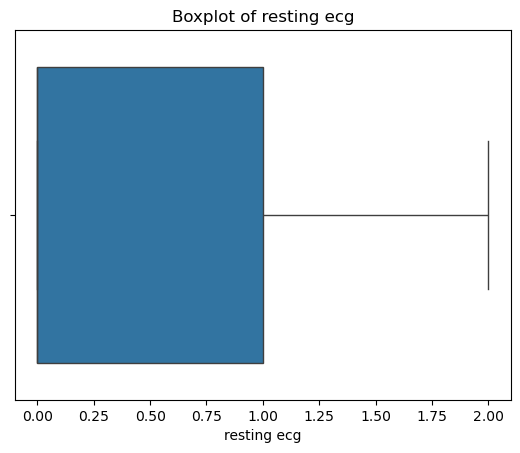

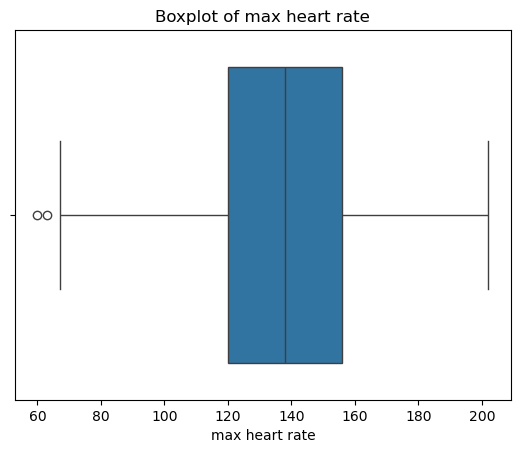

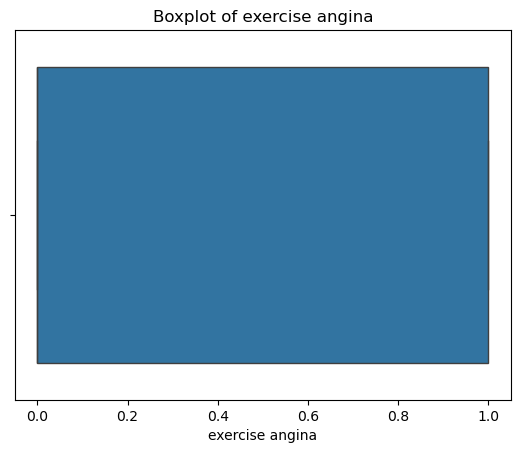

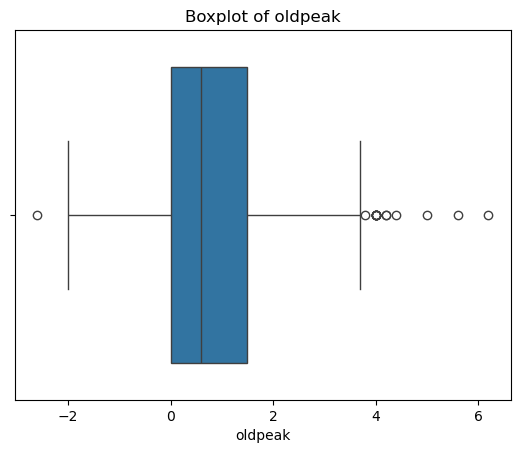

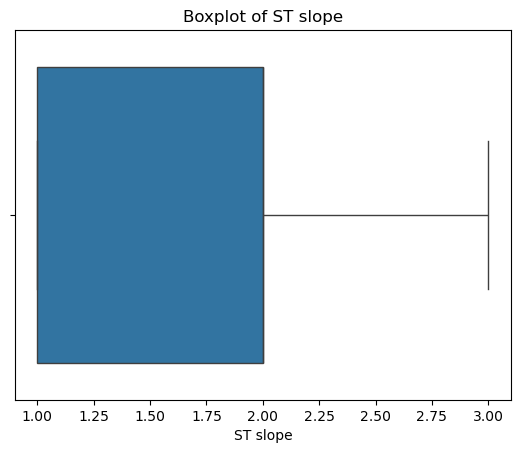

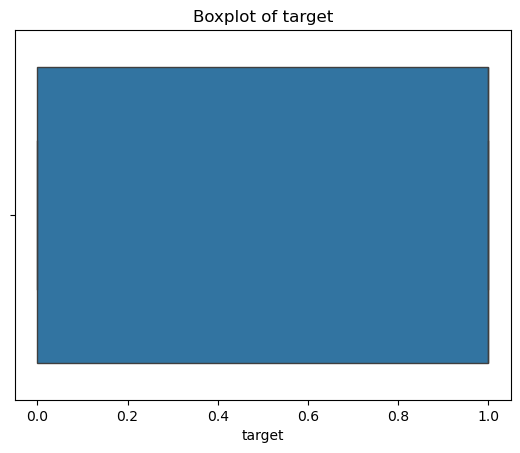

In [22]:
# Boxplot of Every column.
for col in data.columns:
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


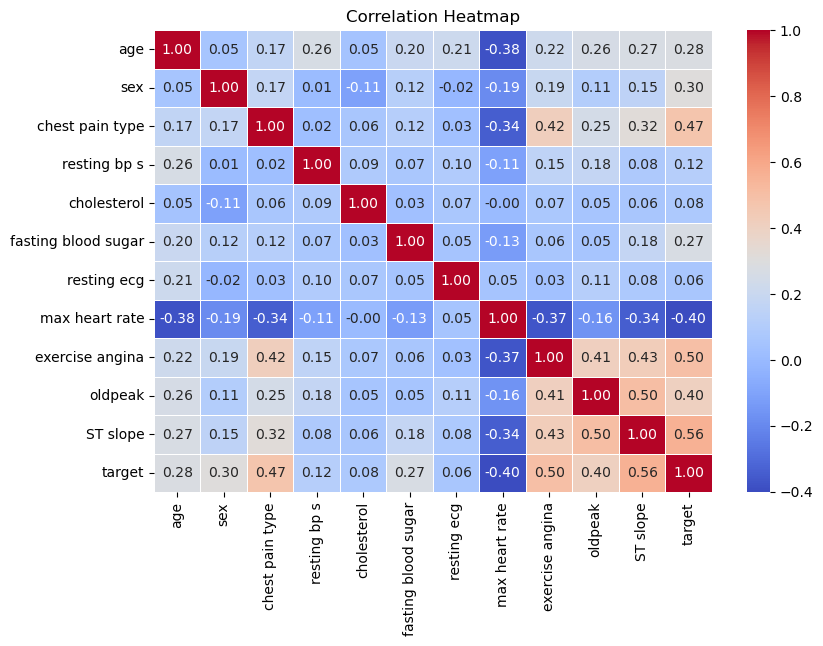

In [23]:
# Heatmap.
plt.figure(figsize=(9,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Train-Test split.

from sklearn.model_selection import train_test_split
X = data.drop('target', axis = 1)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [25]:
# Standard Scaling .
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
## Logistic Regression .

from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

logistic.fit(X_train_scaled,y_train)
y_pred_log = logistic.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

Accuracy = accuracy_score(y_test,y_pred_log)
print(Accuracy)
cm = confusion_matrix(y_test,y_pred_log)
print(cm)
report = classification_report(y_test,y_pred_log)
print(report)


0.8260869565217391
[[66 15]
 [17 86]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.80        81
           1       0.85      0.83      0.84       103

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



In [28]:
# Overfitting.
train_acc = accuracy_score(y_train, logistic.predict(X_train_scaled))
test_acc = accuracy_score(y_test, logistic.predict(X_test_scaled))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8647540983606558
Test Accuracy: 0.8260869565217391


In [29]:
## Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_scaled,y_train)
y_pred_dt = dt.predict(X_test_scaled)


In [30]:
score = accuracy_score(y_test,y_pred_dt)
print(score)
cm = confusion_matrix(y_test,y_pred_dt)
print(cm)
report = classification_report(y_test,y_pred_dt)
print(report)


0.7554347826086957
[[61 20]
 [25 78]]
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        81
           1       0.80      0.76      0.78       103

    accuracy                           0.76       184
   macro avg       0.75      0.76      0.75       184
weighted avg       0.76      0.76      0.76       184



In [31]:
# Overfitting.
train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
test_acc = accuracy_score(y_test, dt.predict(X_test_scaled))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 1.0
Test Accuracy: 0.7554347826086957


In [32]:
## Random Forest.

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled,y_train)
y_pred_rf = rf.predict(X_test_scaled)


In [33]:
score = accuracy_score(y_test,y_pred_rf)
print(score)
cm = confusion_matrix(y_test,y_pred_rf)
print(cm)
report = classification_report(y_test,y_pred_rf)
print(report)


0.875
[[68 13]
 [10 93]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        81
           1       0.88      0.90      0.89       103

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



In [34]:
# Overfitting.
train_acc = accuracy_score(y_train, rf.predict(X_train_scaled))
test_acc = accuracy_score(y_test, rf.predict(X_test_scaled))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 1.0
Test Accuracy: 0.875


In [35]:
#  Hyperparameter Tunning.
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,150,200],
    'max_depth':[None,10,15,20],
    'max_features':['sqrt','log2'],
    'min_samples_split':[2,5,10],
    'max_samples':[0.5,0.75,1]
    }
rf_hype = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv=5,
    n_jobs=-1
)

rf_hype.fit(X_train_scaled,y_train)
y_pred = rf_hype.predict(X_test_scaled)
print(rf_hype.best_params_)
print(rf_hype.best_score_)



{'max_depth': 10, 'max_features': 'sqrt', 'max_samples': 0.75, 'min_samples_split': 2, 'n_estimators': 200}
0.8715497157767217


In [36]:
# Random Forest with best parameters.
from sklearn.ensemble import RandomForestClassifier

final_rf = RandomForestClassifier(n_estimators = 200, max_depth = 10,
                            max_features = 'sqrt', max_samples = 0.75,
                            min_samples_split = 2, random_state=42)
final_rf.fit(X_train_scaled,y_train)
y_pred_rfn = final_rf.predict(X_test_scaled)
print(accuracy_score(y_test,y_pred_rfn))
print(confusion_matrix(y_test,y_pred_rfn))
print(classification_report(y_test,y_pred_rfn))

0.8586956521739131
[[67 14]
 [12 91]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        81
           1       0.87      0.88      0.88       103

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



                Feature  Importance
10             ST slope    0.240606
2       chest pain type    0.128503
9               oldpeak    0.119762
7        max heart rate    0.104556
8       exercise angina    0.091372
0                   age    0.075744
4           cholesterol    0.072393
3          resting bp s    0.071248
1                   sex    0.044653
5   fasting blood sugar    0.026965
6           resting ecg    0.024198


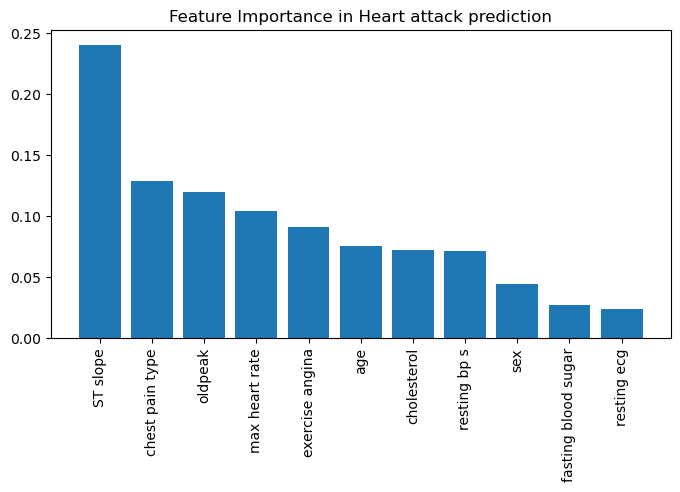

In [37]:
# Feature importance.

importances = final_rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance',ascending=False)

print(importance_df)

plt.figure(figsize=(8,4))
plt.bar(importance_df['Feature'],importance_df['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance in Heart attack prediction")
plt.show()

In [38]:
# Prediction on user input.

import warnings
warnings.filterwarnings('ignore')


new_data = {
    'age': '64',
    'sex': '0',
    'chest pain type': '3',
    'resting bp s' : '130',
    'cholesterol' : '270',
    'fasting blood sugar': '0',
    'resting ecg' : '1',
    'max heart rate' : '134',
    'exercise angina' : '1',
    'oldpeak' : '2.6',
    'ST slope' : '2'
}

# Creating new Dataframe for user input.

new_df = pd.DataFrame([new_data])

new_data = new_df[X_train.columns].astype(float)

#  Prediction

prediction = final_rf.predict(new_data)
if prediction == 0:
  print("No Heart Disease Detected...")
else:
  print('Heart Disease Detected !!!!!!')


Heart Disease Detected !!!!!!
